In [1928]:
# Maximum turnover rates for all reactions (# molecules per protein per minute)
kref = Dict(
"exp" => 90,                     # C/N exporters, molecules of C and N org/min 
"trn" => 90,                     # DIN transporters, atoms of N/min
"trdop" => 90,                   # DOP transporters, atoms of P/min
"trpo4" => 90,                   # PO4 transporters, atoms of P/min
"p" => 3600.0,                      # photosystems, photons/min
"ru" => 258.5,                      # rubisco, atoms of C/min
"ri" => 1307.2,                     # ribosomes, molecules of aa/min
"nt"=> 1607.7,                        # nitrogenase, atoms of N/min 
"gl" => 181.9,                      # glycolysis, atoms of C/min
"lb" => 181.9,                      # lipid synthesis, atoms of C/min
"din" => 4037.6,                    # DIN proteins, atoms of N/min
"dop" => (0.25*16.1)+(0.75*1922.8), # DOP (25% phosphonate dehydrogenase, 75% AP), molecules of DOP/min
"org" => 200.9,                     # synthesis of organic molecules, organic molecules/min
"d" => 1000.0,                      # heat damage, molecules of photosystems/min
"re" => 2000.0,                     # repair from heat damage, molecules of photosystems/min
"nt_d" => 1                         # damage to nitrogenase from oxygen diffusion, molecules of nitrogenase/min
)

# Half-saturation constants for all reactions
K = Dict(
"exp" => 2.0,                         # exporters, uM C/N org molecules
"corg" => 10^4,                     # incorporation of internal carbon by synthesis of organic compounds for export, atoms of C/ μm3
"norg" => 10^4,                     # incorporation of internal nitrogen by synthesis of organic compounds for export, atoms of N/ μm3
"trn" => 2.0,                         # DIN transporters, uM DIN. 
"trdop" => 2.0,                     # DOP transporters, uM DOP
"ic" => 10^4,                       # incorporation of internal carbon by ribosomes, atoms of C/ μm3
"in" => 10^4,                       # incorporation of internal nitrogen by ribosomes, atoms of N/ μm3
"ntn" => 10^4,                      # incorporation of N2 by nitrogenase, atoms of N/μm3. 
"lb" => 10^4,                       # lipid synthesis, atoms of C/μm3
"p" => 80.0,                       # photosystems, photons/μm3
"ru" => 1.0,                        # rubisco, uM DIC
"gl" => 10^4,                       # glycolysis, atoms of C/μm3
"dop" => 2.0,                       # DOP processing, uM DOP
"trpo4" => 2.0,                     # PO4 processing, uM PO4
"d" => 10^4,                        # heat damage, atoms of C/um3
"re" => 10^4,                       # repair, atoms of C/um3
)

# Space and density constraints
s_trn = 1.26e-5                     # um2, specific surface area of membrane transporter molecules
s_lm = 0.5e-6                       # um2, specific surface area of membrane lipid molecules
Mmax = 0.005                        # unitless, maximum membrane transporter to lipid ratio
Mmin = 3e-5                         # unitless, minimum membrane transporter to lipid ratio
Vp = 1.5e-5                         # um3, volume / photosystem
Vnt = 3.7e-7                        # um3, volume / nitrogenase
Vli = 1.5e-9                        # um3, volume / lipid droplet
Vgv = 0.1                           # fraction of total volume, volume of gas vesicles
Dmax = 6.4e11                       # Da/um3, maximum density of the cell
ctag_max = 2e7                    # maximum number of lipid molecules / um3 
ctag_min = 200                      # minimum number of lipid molecules / um3
flmp = 0.554                        # Fraction of membrane lipids that are phospholipids

#Cell size
alpha = 1.0                           # um, maximum biological radius of a Trichodesmium cell 

# Temperature effects
Ttest = 273.0 .+ [3.0:1.0:45.0;]    # K, temperature regime
Tmin = minimum(Ttest)               # K, minimum temperature
Tmax = maximum(Ttest)               # K, maximal temperature
Ea = 4.5                            # eV, activation energy  
Ed = 2.0                            # eV, deactivation energy
Etr = Ea/2                          # eV, activation energy nutrient diffusion
R = 8.62*10^-5                      # eV/K, Boltzmann's constant
Tref = 26+273.0                     # K, reference temperature
Td = 42+273.0                       # K, critical high temperature

# Molecular weights
ηaa = 110                           # Da / amino acid
ηp  = 12739*ηaa                     # Da / molecule of photosystem
ηtrn = 754*ηaa                      # Da / molecule of N transporter 
ηdin = 1989*ηaa                     # Da / molecule of other DIN proteins
ηru = 3110*ηaa                      # Da / molecule of rubisco
ηri = 19323*ηaa                     # Da / molecule of ribosome
ηlb = 13742*ηaa                     # Da / molecule of lipid synthesis pathway proteins
ηgl = 4112*ηaa                      # Da / molecule of glycolysis pathway proteins
ηnt = 7024*ηaa                      # Da / molecule of nitrogenase
ηdop = 728*ηaa                      # Da / molecule of DOP processing proteins
ηtrdop = 1432*ηaa                   # Da / molecule of DOP transporter 
ηtrpo4 = 1272*ηaa                   # Da / molecule of PO4 transporter 
ηexp = 2057*ηaa                     # Da / molecule of exporter
ηorg = 47*ηaa                       # Da / molecule of polysaccharide biosynthesis proteins
ηre = 6350*ηaa                      # aa / molecule of repair proteins
ηot = 9486*ηaa                      # Da / molecule of other proteome
ηin = 14                            # Da / nitrogen atom
ηic = 12                            # Da / carbon atom
ηip = 31                            # Da / phosphorus atom
ηgu = 180                           # 180 Da; 6C glucose
ηli = 800                           # 800 Da; 16C TAG
cot = Dmax/4.9/110/(ηot/ηaa)        # molecules of other proteome / μm3

# Carbon and Nitrogen quotas
Qpt = 0.20                          # Nitrogen to Carbon ratio of proteins
Qp  = 0.10                          # Nitrogen to Carbon ratio of photosystems
Qri = 0.33                          # Nitrogen to Carbon ratio of ribosomes
Qother = 0.20                       # Nitrogen to Carbon ratio of other proteins not simulated here
Pri = (1/8)*0.6                     # Phosphorus to carbon ratio of ribosomes
Ppt = 0.1/4.82                      # Phosphorus to carbon ratio of proteins
ηlic = 16                           # atoms of C/ molecule of lipid
ηguc = 6                            # atoms of C/ molecule of glucose
ηaac = 5                            # atoms of C/ molecule of amino acid
ηatpp = 3                           # atoms of P/ molecule of ATP
ηrup = 2                            # atoms of P/ rubisco molecule
ηglp = 2                            # atoms of P/ glycolysis pathway proteins
ηlip = 1/39                         # atoms of P/ atom of C in phospholipid

# Energy conversion factors
e_p  = 1.0                          # ATP / photon absorbed
e_ru = 10                           # ATP / carbon
e_trn = 1.0                         # ATP / nitrogen
e_trpo4 = 1.0                       # ATP / nitrogen from PO4 transported
e_trdop = 2.0                       # ATP / DOP transported
e_ri = 3+9*5                        # ATP / amino acid
e_lb = 3.9                          # ATP / carbon
e_u  = 9e7/ctag_max                 # ATP / photosystem
e_re = 4.5                          # ATP / photosystem
ep_gl = 5.0                         # ATP produced / carbon in glycolysis
ec_gl = 2.0                         # ATP consumed / carbon in glycolysis
e_ld = 6.6                          # ATP / carbon
e_nt = 8                            # ATP / N atom fixed by nitrogenase
e_din = 5.2                         # ATP / N atom from reduced DIN not including transport
e_dop = 0                           # ATP / P atom from DOP
e_exp = 1                           # ATP / C and N org molecule transported
fdr = 0.3                           # fraction of respiration that happens in the dark
td = 12*60                          # minutes, dark period (12 hours)

720

In [1929]:
# Load packages
using Ipopt
using JuMP
using CSV
using DataFrames
using Plots

# Create a JuMP model, using Ipopt as the solver.
model = Model(Ipopt.Optimizer)

# Set the environment:
@NLparameter(model, T   == 26.0 + 273.0)   # K,  temperature
@NLparameter(model, DIN == 1.0)            # uM, external dissolved inorganic nitrogen
@NLparameter(model, DIC == 100.0)          # uM, external dissolved inorganic carbon
@NLparameter(model, PO4 == 0.1)            # uM, external PO4 
@NLparameter(model, DOP == 0.0)            # uM, external DOP
@NLparameter(model, I   == 320.0)          # μmol photon m-2 s-1, irradiance

I == 320.0

In [1930]:
# Start by running the code with these params

gs_mu = 0.00018325521607508234
gs_pdin = 5.642962650438209
gs_ptrpo4 = 4434.830863305339
gs_ptrn = 120.92426397802097
gs_pnt = 1.348989429023246e-7
gs_pri = 7.108836601225698
gs_plb = 140.60497006713956
gs_pp = 16364.11932356158
gs_pdp = 2399.215652077058      
gs_pru = 774.2820017203877
gs_pgl = 713.6234946691391
gs_pre = 1051.069090649393                        
gs_cin = 170925.76482091576
gs_cip = 63.92363957408251
gs_clm = 1.1353888031317946e6
gs_cic = 767251.4506560541
gs_ctag = 8.200019984571977e7

8.200019984571977e7

In [1931]:
# Define the unknown variables that we will optimize for.
@variables(model, begin
        logμ, (start = gs_mu)              # 1/minute, log growth rate 
        pdin ≥ 0, (start = gs_pdin)        # protein: number of DIN proteins without transporters / μm3
        ptrpo4 ≥ 0, (start = gs_ptrpo4)    # protein: number of PO4 transporters / μm3
        ptrn ≥ 0, (start = gs_ptrn)        # protein: number of  transporters / um3
        pnt ≥ 0, (start = gs_pnt)          # protein: number of  nitrogenasse / um3
        pri ≥ 0, (start = gs_pri)          # protein: number of ribosomes / um3 30
        plb ≥ 0, (start = gs_plb)          # protein: number of lipid biosynthesis pathway proteins / um3
        pp  ≥ 0, (start = gs_pp)           # protein: number of photosystems / um3
        pdp ≥ 0, (start = gs_pdp)          # protein: number of damaged photosystems / um3
        pru ≥ 0, (start = gs_pru)          # protein: number of rubisco / um3
        pgl ≥ 0, (start = gs_pgl)          # protein: number of glycolysis pathway prteins / um3
        pre ≥ 0, (start = gs_pre)          # protein: number of repair proteins / um3
        cin ≥ 0, (start = gs_cin)          # other macromolecule: number of internal nitrogen molecules / um3
        cip ≥ 0, (start = gs_cip)          # other macromolecule: number of internal phosphorus atoms / μm3 
        clm ≥ 0, (start = gs_clm)          # other macromolecule: number of membrane lipids / um3
        cic ≥ 0, (start = gs_cic)          # other macromolecule: number of internal carbon molecules / um3
        ctag≥ 0, (start = gs_ctag)         # other macromolecule: number of lipid droplets / um3
        #Proteome allocations
        ϕtrn ≥ 0, (start = 0.002)          # relative proteome investment in: transporters (unitless)
        ϕdin ≥ 0, (start = 0.002)          # relative proteome investment in: DIN proteins without transporters (unitless)
        ϕtrpo4 ≥ 0, (start = 0.002)        # relative proteome investment in: PO4 transporters (unitless)
        ϕri ≥ 0, (start = 0.04)            # relative proteome investment in: ribosomes (unitless)
        ϕp  ≥ 0, (start = 0.03)            # relative proteome investment in: photosystems (unitless)
        ϕru ≥ 0, (start = 0.07)            # relative proteome investment in: rubisco (unitless)
        ϕgl ≥ 0, (start = 0.15)            # relative proteome investment in: glycolysis (unitless)
        ϕnt  ≥ 0, (start = 0.02)           # relative proteome investment in: nitrogenase (unitless)
        ϕre ≥ 0, (start = 0.01)            # relative proteome investment in: repair (unitless)
        β   ≥ 0, (start = 1.7)             # um, cellular volume to surface area ratio 
        ϕlb ≥ 0, (start = 0.002)           # relative proteome investment in: lipid biosynthesis (unitless)
        αlm ≥ 0, (start = 0.2)             # fraction of lipid synthesis flux used to: synthesize membrane lipids (unitless)
        αtag≥ 0, (start = 0.6)             # fraction of lipid synthesis flux used to: synthesize lipid storage (unitless)
end)

(logμ, pdin, ptrpo4, ptrn, pnt, pri, plb, pp, pdp, pru, pgl, pre, cin, cip, clm, cic, ctag, ϕtrn, ϕdin, ϕtrpo4, ϕri, ϕp, ϕru, ϕgl, ϕnt, ϕre, β, ϕlb, αlm, αtag)

In [1933]:
# Set the objective: maximize the log growth rate (logμ).
@objective(model, Max, logμ)

logμ

In [1934]:
# Define any intermediate calculations.
@NLexpressions(model, begin
        #Rate constants
        γTa,   exp(Ea*(1.0/(R*Tref) - 1.0/(R*T)))                                              # rate constant for enzymes; unitless
        γTd,   exp(Ed*(1.0/(R*Td) - 1.0/(R*T)))                                                # rate constant for temperature-dependent damage; unitless
        γTad,  exp(Etr*(1.0/(R*Tref) - 1.0/(R*T)))                                             # rate constant for nitrogen transport; unitless
        γTm,   (Tmax - T)/(Tmax - Tmin)                                                        # unitless
        #Reaction rates 
        vp,  ( kref["p"] ) * pp * I / (K["p"] + I)                                             # photosystems reaction rate; molecules of photons/μm3/min
        vru, ( kref["ru"] * γTa ) * pru * DIC / ( K["ru"] + DIC)                               # rubisco reaction rate; atoms of carbon/μm3/min
        vtrn, ( kref["trn"] * γTad ) * ptrn * DIN/ ( K["trn"] + DIN)                           # DIN reaction rate (limited by the nitrogen transporters reaction rate); atoms of nitrogen/μm3/min
        vri, ( kref["ri"] * γTa ) * pri * (cic / ( K["ic"] + cic )) *                          # Ribosome reaction rate (limited by the nitrogen transporters reaction rate); atoms of nitrogen/μm3/min
        (cin / ( K["in"] + cin))                                                               # protein synthesis rate; molecules of amino acids/μm3/min
        vlb, ( kref["lb"] * γTa ) * plb * cic / ( K["lb"] + cic )                              # lipid synthesis rate; atoms of carbon/μm3/min
        vgl,   ( kref["gl"] * γTa ) * pgl                                                      # glycolysis rate; atoms of carbon/μm3/min 
        vnt,   ( kref["nt"] * γTa ) * pnt                                                      # N2 fixation rate; atoms of nitrogen/μm3/min  
        vd,  ( kref["d"]  * γTd ) * pp * (ctag_max/ctag)                                       # rate of heat damage; molecules of photosystems/μm3/min                                                                          
        vre,  ( kref["re"]  * γTa ) * pre * (pdp/(pdp + pp))                                   # rate of repair; molecules of photosystems/μm3/min
        vtrpo4, ( kref["trpo4"] * γTad) * ptrpo4 * (PO4 / (K["trpo4"] + PO4))                  # PO4 processing rate; molecules of PO4/μm3/min
        #Cell dimensions
        r, 3/β
        vol, 4/3*π*(r)^3                                                                       # um3; cell biovolume
        Vn, 0.3                                                                                # um3, volume / nucleoid
        ϵ, 1.0 - (pp + pdp) * Vp  - (ctag * Vli)  - (Vn/vol) - Vgv                             # fraction of the biovolume not occupied by photosystems nor lipid storage; unitless  
        vnt_d,  ( kref["nt_d"]  * γTd ) * pnt * (alpha/r)                                      # rate of nitrogenase damage; molecules of photosystems/μm3/min
        #Macromolecule pools
        cgu, vgl / ηguc * td                                                                   # storage pool for glucose to fuel dark respiration; molecules of glucose/μm3
        ηaan, ηaac * ((ϕtrn + ϕru + ϕgl + ϕlb + ϕnt + ϕdin                                     # atoms of nitrogen / molecule of amino acid
        + ϕtrpo4 + ϕre)*Qpt + ϕri*Qri + ϕp*Qp)                                
        tot_p, pp*ηp + pru*ηru + ptrn*ηtrn + pdin*ηdin + pri*ηri + pgl*ηgl +                   # total protein content; Da/μm3
        + ptrpo4*ηtrpo4 + pnt*ηnt + 
        plb*ηlb + pre*ηre + cot*ηot                                                          
        ecost, vtrn*(e_trn+e_din) + vri*e_ri +                                                 # energetic demands of photosystems other than rubisco; molecules of ATP/μm3/min
        vtrpo4*e_trpo4 + vlb*e_lb + vd*e_u + vre*e_re                                  
        D, ηru*pru + ηri*pri + ηnt*pnt + pdin*ηdin + ηgl*pgl + ηre*pre                         # concentration of all macromolecules except for photosystems, lipid storage and membrane components; Da/μm3 
        + plb*ηlb + ηin*cin + ηic*cic + ηip*cip + cgu*ηgu + cot*ηot                             
        #Element concentrations
        atp, (ecost/exp(logμ))*0.001                                                           # total molecules of ATP in the cell/μm3
        Qn,   (ptrn*ηtrn*Qpt + pdin*ηdin*Qpt + pru*ηru*Qpt + pgl*ηgl*Qpt + plb*ηlb*Qpt +       # total number of atoms of nitrogen/μm3
        pri*ηri*Qri + pnt*ηnt*Qpt + ptrpo4*ηtrpo4*Qpt + 
        pp*ηp*Qp + pre*ηre*Qpt + cot*ηot*Qpt)* ηaac/ηaa + cin                                        
        Qc,   (ptrn*ηtrn + pdin*ηdin + pru*ηru + pgl*ηgl + pp*ηp + pre*ηre +                   # total number of atoms of carbon/μm3
        plb*ηlb + pri*ηri + pnt*ηnt + 
        ptrpo4*ηtrpo4 + cot*ηot)*ηaac/ηaa + cic + clm*ηlic + ctag*ηlic + cgu*ηguc         
        Qp, (ptrn*ηtrn*Ppt + pri*ηri*Pri + plb*ηlb*Ppt + pnt*ηnt*Ppt +ptrn*ηtrn*Ppt +          # total number of atoms of phosphorus/μm3
        pre*ηre*Ppt + ptrpo4*ηtrpo4*Ppt + pp*ηp*Ppt + cot*ηot*Ppt)* ηaac/ηaa
         +(clm*flmp*ηlic*ηlip) + 
        pru*ηrup + pgl*ηglp + atp*3 + cip             
        Qcell, Qc/Qn                                                                           # carbon to nitrogen quota of the cell
        Pcell, Qc/Qp                                                                           # carbon to phosphorus quota of the cell
        
end)

(subexpression[1]: exp(4.5 * (1.0 / (8.62e-5 * 299.0) - 1.0 / (8.62e-5 * T))), subexpression[2]: exp(2.0 * (1.0 / (8.62e-5 * 315.0) - 1.0 / (8.62e-5 * T))), subexpression[3]: exp(2.25 * (1.0 / (8.62e-5 * 299.0) - 1.0 / (8.62e-5 * T))), subexpression[4]: (318.0 - T) / (318.0 - 276.0), subexpression[5]: (3600.0 * pp * I) / (80.0 + I), subexpression[6]: ((258.5 * subexpression[1]) * pru * DIC) / (1.0 + DIC), subexpression[7]: ((90.0 * subexpression[3]) * ptrn * DIN) / (2.0 + DIN), subexpression[8]: (1307.2 * subexpression[1]) * pri * (cic / (10000.0 + cic)) * (cin / (10000.0 + cin)), subexpression[9]: ((181.9 * subexpression[1]) * plb * cic) / (10000.0 + cic), subexpression[10]: (181.9 * subexpression[1]) * pgl, subexpression[11]: (1607.7 * subexpression[1]) * pnt, subexpression[12]: (1000.0 * subexpression[2]) * pp * (2.0e7 / ctag), subexpression[13]: (2000.0 * subexpression[1]) * pre * (pdp / (pdp + pp)), subexpression[14]: (90.0 * subexpression[3]) * ptrpo4 * (PO4 / (2.0 + PO4)), subex

In [1935]:
# Define the system of equations and constraints.
@constraints(model, begin
        ϕp + ϕru + ϕtrn + ϕdin + ϕri + ϕgl + ϕnt +                                             # the sum of all proteome relative investments is assumed to equal 1 - ϕother
        ϕtrpo4 + ϕlb + ϕre ==  0.5 
        αlm + αtag == 1.0                                                                      # the lipids pool is comprised of the flux used to synthesize membrane lipids (αlm), and the storage ones (αtag) 
        # ϕnt ==0 
end)

(ϕtrn + ϕdin + ϕtrpo4 + ϕri + ϕp + ϕru + ϕgl + ϕnt + ϕre + ϕlb = 0.5, αlm + αtag = 1)

In [1936]:
@NLconstraints(model, begin
        # h == 16.2                                                                           # constraint on the maximum length of cells based on Cleveland et al. measurements
        ϵ ≥ 0
        (ptrn + ptrpo4) / (clm) ≤ Mmax                                                        # constraint on the transporter to lipid ratio in the membrane
        vtrn /kref["din"] ≤ pdin                                                              # constraint on the ratio of N transporter to DIN proteins
        β == (s_trn * (ptrn + ptrpo4) +                                                       # constraint on the volume to surface area ratio of the cell
        s_lm * clm)                                                               
        pdp / (pdp + pp) == ( ( kref["d"]  * γTd ) * pp * (ctag_max/ctag) ) /                 # damage (vd) and repair (vre) dynamics assuming vd = vre
        ( kref["re"] * γTa * pre )                                                             
        ϕp * vri * 1/(ηp/ηaa) - exp(logμ) * (pp) == 0.0                                       # protein: molecules of photosystems/μm3
        ϕru * vri * 1/(ηru/ηaa) - exp(logμ) * pru == 0.0                                      # protein: rubisco/μm3
        ϕtrn  * vri * 1/(ηtrn/ηaa) - exp(logμ) * ptrn  == 0.0                                 # protein: N transporters/μm3
        ϕdin  * vri * 1/(ηdin/ηaa)  - exp(logμ) * pdin  == 0.0                                # protein: DIN proteins/μm3
        ϕri * vri * 1/(ηri/ηaa) - exp(logμ) * pri == 0.0                                      # protein: ribosomes/μm3
        ϕnt * vri * 1/(ηnt/ηaa) - vnt_d - exp(logμ) * pnt == 0.0                                     # protein: nitrogenase/μm3
        ϕlb * vri * 1/(ηlb/ηaa) - exp(logμ) * plb == 0.0                                      # protein: lipid synthesis proteins/μm3
        ϕgl * vri * 1/(ηgl/ηaa) - exp(logμ) * pgl == 0.0                                      # protein: glycolysis proteins/μm3
        ϕre * vri * 1/(ηre/ηaa) - exp(logμ) * pre == 0.0                                      # protein: pre/μm3
        ϕtrpo4 * vri * 1/(ηtrpo4/ηaa) - exp(logμ) * ptrpo4 == 0.0                             # protein: PO4 transporters/μm3
        vtrn + vnt - vri*ηaan - exp(logμ) * cin == 0.0                                        # internal pool of nitrogen/μm3
        vru - vri*ηaac - vlb - vgl - exp(logμ) * cic == 0.0                                   # internal pool of carbon/μm3
        vtrpo4  - vgl*ec_gl*ηatpp/ηguc - vri*ϕru*ηrup*ηaa/(ηaac*ηru) -                        # internal pool of phosphorus/μm3
        exp(logμ)*clm*flmp*ηlip - exp(logμ) * cip == 0.0                           
        αlm * vlb/ηlic - exp(logμ) * clm == 0.0                                               # membrane lipids/μm3 (evolved)
        αtag * vlb/ηlic - exp(logμ) * ctag == 0.0                                             # lipid storage/μm3 (used to regulate heat-damage; not used in dark respiration)
        ctag ≤ ctag_min + ctag_max                                                            # constraint on the maximum concentration of ctag; lipid storage/μm3
        # energetic requirements:
        vp * e_p ≥ vru * e_ru + vnt * e_nt                                                    # rubisco costs are paid by photosystems; molecules of ATP/μm3/min
        ecost ≤ vp * e_p - vru * e_ru - vnt * e_nt                                            # total ATP cost; molecules of ATP/μm3/min
        ecost*fdr + vnt*e_nt ≤ vgl*ep_gl                                                      # dark respiration; molecules of ATP/μm3/min
        1/ϵ * D ≤ Dmax                                                                        # density constraint; Da/μm3  
end)

(subexpression[18] - 0.0 ≥ 0, (ptrn + ptrpo4) / clm - 0.005 ≤ 0, (subexpression[7] / 4037.6 - pdin) - 0.0 ≤ 0, (β - (1.26e-5 * (ptrn + ptrpo4) + 5.0e-7 * clm)) - 0.0 = 0, (pdp / (pdp + pp) - ((1000.0 * subexpression[2]) * pp * (2.0e7 / ctag)) / (2000.0 * subexpression[1] * pre)) - 0.0 = 0, ((ϕp * subexpression[8] * 1.0) / (1.40129e6 / 110.0) - exp(logμ) * pp) - 0.0 = 0, ((ϕru * subexpression[8] * 1.0) / (342100.0 / 110.0) - exp(logμ) * pru) - 0.0 = 0, ((ϕtrn * subexpression[8] * 1.0) / (82940.0 / 110.0) - exp(logμ) * ptrn) - 0.0 = 0, ((ϕdin * subexpression[8] * 1.0) / (218790.0 / 110.0) - exp(logμ) * pdin) - 0.0 = 0, ((ϕri * subexpression[8] * 1.0) / (2.12553e6 / 110.0) - exp(logμ) * pri) - 0.0 = 0, (((ϕnt * subexpression[8] * 1.0) / (772640.0 / 110.0) - subexpression[19]) - exp(logμ) * pnt) - 0.0 = 0, ((ϕlb * subexpression[8] * 1.0) / (1.51162e6 / 110.0) - exp(logμ) * plb) - 0.0 = 0, ((ϕgl * subexpression[8] * 1.0) / (452320.0 / 110.0) - exp(logμ) * pgl) - 0.0 = 0, ((ϕre * subexpressi

In [1937]:
# Solve the optimization problem.
status = optimize!(model)

In [1938]:
# Optimal solutions looping over different environmental conditions.
env = "Light" # should be one of the following: [DIN], Temperature (C°), "Light", "[DOP]", "[PO4]"

if env == "[DIN]"
    # Run varying [DIN].
    change_DIN = 10.0 .^ [-7.0:0.18:log10(20.0);]
    change_T = 26.0 + 273.0
    change_I = 320.0
    change_DOP = 0.0
    change_PO4 = 0.5
elseif env == "Temperature (C°)"
    # Run varying Temperature.
    change_DIN = 0.0
    change_T  = 273.0 .+ [0.0:0.4:40.0;]
    change_I = 96.0
    change_DOP = 0.0
    change_PO4 = 10
elseif env == "Light"
    # Run varying Light.
    change_DIN = 0.0
    change_T = 28.0 + 273.0
    change_I = [0.1:2.5:310.0;]
    change_DOP = 0.0
    change_PO4 = 4.0
elseif env == "[DOP]"
    # Run varying DOP.
    change_DIN = 1.0
    change_T = 26.0 + 273.0
    change_I = 320.0
    change_DOP = 10.0 .^ [-1.0:0.2:log10(10.0);]
    change_PO4 = 0.0
elseif env == "[PO4]"
    # Run varying PO4.
    change_DIN = 1.0
    change_T = 26.0 + 273.0
    change_I = 320.0
    change_DOP = 0.0
    change_PO4 = 10.0 .^ [-3.0:0.1:log10(3.2);]
end

4.0

In [1939]:
# Define empty vectors
s_μ     = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_β     = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
# s_h     = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
# s_r     = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ptrn   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_pdin   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_pri   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_plb   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_pp    = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_pdp    = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_pru   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_pgl   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_pre   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_pnt   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ptrpo4  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ϕtrn   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ϕdin   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ϕri   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ϕlb   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ϕp    = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ϕru   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ϕgl   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ϕre   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ϕnt   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ϕtrpo4  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_cin   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_clm   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_cic   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_cip   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_Qcell = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_Pcell = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_Qc    = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_Qn    = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_Qp    = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_vru   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_vp    = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_vgl   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_vd    = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_vre    = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_vlb   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_vri   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_vtrn   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_vol   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_vnt   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_vtrpo4  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_totp  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_D     = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_γTa   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_γTd   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_γTad  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_γTm   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_cgu   = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ecost = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ηaan  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ϵ     = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_ctag = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_αlm  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_αtag  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_T  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_DIN  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_I  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
s_po4  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
# s_sa  = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))
# s_transporter_sa_vol = Array{Float64,5}(undef,length(change_T),length(change_DIN),length(change_I),length(change_DOP),length(change_PO4))

1×1×124×1×1 Array{Float64, 5}:
[:, :, 1, 1, 1] =
 1.2e-322

[:, :, 2, 1, 1] =
 1.04e-322

[:, :, 3, 1, 1] =
 1.4e-322

;;; … 

[:, :, 122, 1, 1] =
 8.0e-323

[:, :, 123, 1, 1] =
 1.2e-322

[:, :, 124, 1, 1] =
 1.2e-322

In [1940]:
# Store model output in empty vectors
for i in 1:length(change_DIN)
    set_value(DIN, change_DIN[i])
    for j in 1:length(change_T)
            set_value(T, change_T[j])
            for k in 1:length(change_I)
                    set_value(I, change_I[k])
                    for o in 1:length(change_DOP)
                            set_value(DOP, change_DOP[o])
                            for p in 1:length(change_PO4)
                                set_value(PO4, change_PO4[p])
                                optimize!(model)
                                s_μ[j,i,k,o,p]   = exp.(JuMP.value.(logμ))
                                s_β[j,i,k,o,p]   = value(β)
                                s_ptrn[j,i,k,o,p] = JuMP.value.(ptrn)
                                s_pdin[j,i,k,o,p] = JuMP.value.(pdin)
                                s_pri[j,i,k,o,p] = JuMP.value.(pri)
                                s_plb[j,i,k,o,p] = JuMP.value.(plb)
                                s_pp[j,i,k,o,p]  = JuMP.value.(pp)
                                s_pdp[j,i,k,o,p]  = JuMP.value.(pdp)
                                s_pru[j,i,k,o,p] = JuMP.value.(pru)
                                s_pgl[j,i,k,o,p] = JuMP.value.(pgl)
                                s_pre[j,i,k,o,p] = JuMP.value.(pre)
                                s_pnt[j,i,k,o,p] = JuMP.value.(pnt)
                                s_ptrpo4[j,i,k,o,p] = JuMP.value.(ptrpo4)
                                s_ϕtrn[j,i,k,o,p] = JuMP.value.(ϕtrn)
                                s_ϕdin[j,i,k,o,p] = JuMP.value.(ϕdin)
                                s_ϕri[j,i,k,o,p] = JuMP.value.(ϕri)
                                s_ϕlb[j,i,k,o,p] = JuMP.value.(ϕlb)
                                s_ϕp[j,i,k,o,p]  = JuMP.value.(ϕp)
                                s_ϕru[j,i,k,o,p] = JuMP.value.(ϕru)
                                s_ϕgl[j,i,k,o,p] = JuMP.value.(ϕgl)
                                s_ϕre[j,i,k,o,p] = JuMP.value.(ϕre)
                                s_ϕnt[j,i,k,o,p] = JuMP.value.(ϕnt)
                                s_ϕtrpo4[j,i,k,o,p] = JuMP.value.(ϕtrpo4)
                                s_cin[j,i,k,o,p] = JuMP.value.(cin)
                                s_clm[j,i,k,o,p] = value(clm)
                                s_cic[j,i,k,o,p]  = JuMP.value.(cic)
                                s_cip[j,i,k,o,p]  = JuMP.value.(cip)
                                s_Qcell[j,i,k,o,p] = value(Qcell)
                                s_Pcell[j,i,k,o,p] = value(Pcell)
                                s_Qc[j,i,k,o,p] = value(Qc)
                                s_Qn[j,i,k,o,p] = value(Qn)
                                s_Qp[j,i,k,o,p] = value(Qp)
                                s_vru[j,i,k,o,p]  = value(vru)
                                s_vp[j,i,k,o,p]   = value(vp)
                                s_vgl[j,i,k,o,p]  = value(vgl)
                                s_vre[j,i,k,o,p]  = value(vre)
                                s_vd[j,i,k,o,p]  = value(vd)
                                s_vlb[j,i,k,o,p] = value(vlb)
                                s_vri[j,i,k,o,p]  = value(vri)
                                s_vtrn[j,i,k,o,p]  = value(vtrn)
                                s_vol[j,i,k,o,p]  = value(vol)
                                s_vnt[j,i,k,o,p] = value(vnt)
                                s_vtrpo4[j,i,k,o,p]  = value(vtrpo4)
                                s_totp[j,i,k,o,p] = value(tot_p)
                                s_D[j,i,k,o,p]    = value(D)
                                s_γTa[j,i,k,o,p]  = value(γTa)
                                s_γTd[j,i,k,o,p]  = value(γTd)
                                s_γTad[j,i,k,o,p] = value(γTad)
                                s_γTm[j,i,k,o,p]  = value(γTm)
                                s_cgu[j,i,k,o,p]  = value(cgu)
                                s_ecost[j,i,k,o,p] = value(ecost)
                                s_ηaan[j,i,k,o,p]  = value(ηaan)
                                s_ϵ[j,i,k,o,p]    = value(ϵ)
                                s_ctag[j,i,k,o,p]  = JuMP.value.(ctag)
                                s_αlm[j,i,k,o,p]  = JuMP.value.(αlm)
                                s_αtag[j,i,k,o,p]  = JuMP.value.(αtag)
                                s_T[j,i,k,o,p] = value(T)
                                s_DIN[j,i,k,o,p] = value(DIN)
                                s_I[j,i,k,o,p] = value(I)
                                s_po4[j,i,k,o,p] = value(PO4)
                            end        
                    end
            end
    end
end

In [1942]:
using CSV
using DataFrames

a = length(change_T)
b = length(change_DIN)
c = length(change_I)
d = length(change_DOP)
e = length(change_PO4)

1

In [1943]:
# Reshape the array into a 1-dimensional array
temp = reshape(s_T .- 273.0, (a * b * c * d * e , 1))
volume = reshape(s_vol, (a * b * c * d * e , 1))
mu = reshape(s_μ *60*24, (a * b * c * d * e , 1))
beta = reshape(s_β, (a * b * c * d * e , 1))
NC = reshape(s_Qcell, (a * b * c * d * e , 1))
phot = reshape(s_vru, (a * b * c * d * e , 1))
totp = reshape(s_totp, (a * b * c * d * e , 1))
icbd = reshape(s_ϕgl, (a * b * c * d * e , 1))
ichl = reshape(s_ϕp, (a * b * c * d * e , 1))
itrn = reshape(s_ϕtrn, (a * b * c * d * e , 1)) 
idin = reshape(s_ϕdin, (a * b * c * d * e , 1)) 
ilpb = reshape(s_ϕlb, (a * b * c * d * e , 1))
irib = reshape(s_ϕri, (a * b * c * d * e , 1))
irub = reshape(s_ϕru, (a * b * c * d * e , 1))
init = reshape(s_ϕnt, (a * b * c * d * e , 1)) 
itrpo4 = reshape(s_ϕtrpo4, (a * b * c * d * e , 1)) 
eps = reshape(s_ϵ, (a * b * c * d * e , 1))  
clip = reshape(s_clm, (a * b * c * d * e , 1))
ctrn = reshape(s_ptrn, (a * b * c * d * e , 1)) 
cdin = reshape(s_pdin, (a * b * c * d * e , 1)) 
cp = reshape(s_pp, (a * b * c * d * e , 1))
cri = reshape(s_pri, (a * b * c * d * e , 1))
cru = reshape(s_pru, (a * b * c * d * e , 1))
cgl = reshape(s_pgl, (a * b * c * d * e , 1))
cnt = reshape(s_pnt, (a * b * c * d * e , 1)) 
ctrpo4 = reshape(s_ptrpo4, (a * b * c * d * e , 1))  
cgu = reshape(s_cgu, (a * b * c * d * e , 1))
ctag = reshape(s_ctag, (a * b * c * d * e , 1))
vtrn = reshape(s_vtrn, (a * b * c * d * e , 1)) 
vnt = reshape(s_vnt, (a * b * c * d * e , 1)) 
vtrpo4 = reshape(s_vtrpo4, (a * b * c * d * e , 1)) 
ecost = reshape(s_ecost, (a * b * c * d * e , 1))
Qcell = reshape(s_Qcell, (a * b * c * d * e , 1))
Pcell = reshape(s_Pcell, (a * b * c * d * e , 1))
Qc = reshape(s_Qc, (a * b * c * d * e , 1))
Qn = reshape(s_Qn, (a * b * c * d * e , 1))
Qp = reshape(s_Qp, (a * b * c * d * e , 1))
cic = reshape(s_cic, (a * b * c * d * e , 1))
cin = reshape(s_cin, (a * b * c * d * e , 1))
cip = reshape(s_cip, (a * b * c * d * e , 1)) 
naan= reshape(s_ηaan, (a * b * c * d * e , 1))
vgl = reshape(s_vgl, (a * b * c * d * e , 1))
vp = reshape(s_vp, (a * b * c * d * e , 1))
vri = reshape(s_vri, (a * b * c * d * e , 1))
din = reshape(s_DIN, (a * b * c * d * e , 1))
light = reshape(s_I, (a * b * c * d * e , 1))
po4 = reshape(s_po4, (a * b * c * d * e , 1))

124×1 Matrix{Float64}:
 4.0
 4.0
 4.0
 4.0
 4.0
 4.0
 4.0
 4.0
 4.0
 4.0
 ⋮
 4.0
 4.0
 4.0
 4.0
 4.0
 4.0
 4.0
 4.0
 4.0

In [1944]:
#Make dataframe to visualize results
output =  DataFrame(
    "eps" => eps[:], 
    "temp" => temp[:], 
    "volume" => volume[:], 
    "mu" => mu[:], 
    "beta" => beta[:],
    "radius" => 3 ./beta[:],
    "NC" => NC[:], 
    "phot" => phot[:], 
    "totp" => totp[:], 
    "icbd" => icbd[:], 
    "ichl" => ichl[:], 
    "itrn" => itrn[:],
    "idin" => idin[:],
    "irib" => irib[:], 
    "irub" => irub[:], 
    "init" => init[:],
    "itrpo4" => itrpo4[:],
    "ilpb" => ilpb[:],
    "clip" => clip[:], 
    "ctrn" => ctrn[:], 
    "cdin" => cdin[:], 
    "cp" => cp[:], 
    "cri" => cri[:], 
    "cru" => cru[:], 
    "cgl" => cgl[:], 
    "cnt" => cnt[:],
    "ctrpo4" => ctrpo4[:],
    "cgu" => cgu[:], 
    "ctag" => ctag[:], 
    "vtrn" => vtrn[:], 
    "vnt" => vnt[:], 
    "vtrpo4" => vtrpo4[:],
    "ecost" => ecost[:],
    "Qcell" => Qcell[:], 
    "Pcell" => Pcell[:],
    "Qc" => Qc[:], 
    "Qn" => Qn[:], 
    "Qp" => Qp[:],
    "cic" => cic[:], 
    "cin" => cin[:],
    "cip" => cip[:],
    "naan" => naan[:], 
    "vgl" => vgl[:],
    "vp" => vp[:], 
    "vri" => vri[:],
    "DIN" => din[:], 
    "light" => light[:],
    "po4" => po4[:],
    )

Row,eps,temp,volume,mu,beta,radius,NC,phot,totp,icbd,ichl,itrn,idin,irib,irub,init,itrpo4,ilpb,clip,ctrn,cdin,cp,cri,cru,cgl,cnt,ctrpo4,cgu,ctag,vtrn,vnt,vtrpo4,ecost,Qcell,Pcell,Qc,Qn,Qp,cic,cin,cip,naan,vgl,vp,vri,DIN,light,po4
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.281105,28.0,3.42116e10,0.008321,0.00148968,2013.85,5.00017,0.00712773,1.30613e11,0.0132326,0.0528892,0.0540829,0.0532896,0.0535036,0.0541586,0.0547372,0.0552025,0.0548833,0.581757,0.00025819,8.84094e-6,1.03495e-6,1.46707e-5,8.7294e-6,0.483247,8.31343e-7,0.130857,33652.0,0.929266,0.0,0.00426396,14.0237,6713.49,5.00017,48.2017,5.93714e9,1.18739e9,1.23173e8,282.069,23.7468,398.756,0.508368,280.433,4.65148e-6,3.97621e-6,0.0,0.1,4.0
2,0.899928,28.0,4.02842e14,0.00390572,6.54796e-5,45815.8,5.0,0.00285826,1.30612e11,0.00605263,0.000454141,0.0118554,0.0118807,0.0120847,0.0041838,0.000492862,-9.06509e-9,0.452998,10.4839,0.000460934,0.00468015,-2.62673e-13,0.00156638,3.50054e-6,0.000137384,1.19301e-8,0.000693918,9.56707,0.0759582,0.0,6.11896e-5,0.0743657,0.085887,5.0,48.2,5.93692e9,1.18738e9,1.23173e8,6.25522,17.4916,8.8138,0.50763,0.0797256,-2.97653e-11,7.1303e-6,0.0,2.6,4.0
3,0.877529,28.0,6.31397e6,2.64773e-7,0.0261648,114.658,5.1976,0.166229,1.33855e11,0.00621739,0.00802649,0.00310285,0.0115625,0.00425881,0.00637726,0.00333054,0.00881907,0.0133656,52327.5,0.0791366,6.13792,0.00931597,1.09996,0.000203583,0.000104681,1.23569e-6,0.000566858,7.28971,1.49805e7,0.0,0.00633784,0.060749,-0.836548,5.1976,50.1037,6.32485e9,1.21688e9,1.26235e8,0.595584,0.5699,4349.96,0.498755,0.0607476,2.00989,1.55682e-5,0.0,5.1,4.0
4,0.858034,28.0,16150.0,4.45664e-5,0.19132,15.6806,5.06363,10236.2,5.87946e11,6.88732e-6,3.71015e-5,0.000121407,0.00443511,0.000466848,7.77203e-6,0.00142828,6.02139e-6,1.86182e-5,3.47031e5,1329.62,18522.9,796.727,197.966,12.5364,15.4065,0.0251653,83.4255,1.07286e6,1.99977e7,0.0,129.073,8940.54,1.45316e5,5.06363,49.0367,2.70568e10,5.34336e9,5.51766e8,3.14434,9.84033e5,65113.6,0.500285,8940.54,2.48841e5,256.899,0.0,7.6,4.0
5,0.874364,28.0,1.00306e5,0.00210318,0.104082,28.8235,5.18857,162.986,1.6045e11,-9.97129e-9,0.499514,1.45237e-6,3.095e-9,2.84639e-8,0.000123499,0.000593744,1.42169e-6,3.51429e-6,189637.0,626.738,3.25279,10.6203,2.34606,0.19961,0.294235,0.000341503,1.593,20489.7,1.69826e7,0.0,1.75157,170.719,2640.25,5.18857,49.9967,7.56806e9,1.4586e9,1.51371e8,0.327424,3950.44,1.04937e5,0.250484,170.748,4285.82,0.0907116,0.0,10.1,4.0
6,0.870428,28.0,91689.4,1.17466e-10,0.107245,27.9733,5.26488,0.615284,1.32029e11,0.00608343,0.030727,0.0911994,3.94116e-7,0.000134112,0.0121386,0.0056899,0.01426,0.00786074,2.14257e5,9.28122,81.9379,0.0333307,13.4949,0.000753545,0.00105329,3.56204e-7,0.00570303,73.348,1.97121e7,0.0,0.00182697,0.611182,10.1262,5.26488,50.7384,6.32013e9,1.20043e9,1.24563e8,0.000899472,0.00768104,1392.36,0.484724,0.611233,16.327,3.88819e-9,0.0,12.6,4.0
7,0.644432,28.0,2726.85,3.85468e-9,0.346149,8.66678,5.74093,2.8734e5,1.50982e11,0.0456996,0.0400808,0.0395143,0.105282,0.06295,0.0474094,0.0586733,0.0220487,0.0391748,6.22512e5,88.0852,19.4885,13526.4,3.09382,351.908,495.149,1.02739e-12,2681.21,3.44808e7,1.91172e7,0.0,5.26947e-9,2.8734e5,4.42908e6,5.74093,51.9829,7.38552e9,1.28647e9,1.42076e8,9.36161e-9,25603.8,1.11954e5,0.520877,2.8734e5,7.7318e6,8.68607e-9,0.0,15.1,4.0
8,0.00283416,28.0,115.438,0.055936,0.993195,3.02056,6.5963,1.1798e6,1.92699e11,0.0058873,0.471457,6.74864e-10,2.70158e-9,0.000197113,0.00394969,0.0039143,0.00986156,0.000288486,1.76411e6,0.00101832,0.00154533,42106.1,11.6059,1444.91,1628.92,2.27932,8820.57,1.13434e8,2.00002e7,0.0,11690.6,9.45283e5,1.54429e7,6.5963,54.1918,9.78829e9,1.48391e9,1.80623e8

In [1945]:
# CSV.write("model_output.csv", output, header = true)

In [1946]:
# Convert temperature to degree Celsius
change_T = change_T .- 273.0

28.0

In [1947]:
using Plots
using Printf
gr()

Plots.GRBackend()

In [1948]:
# Set threshold
up_threshold = 0.3
low_threshold= -0.00001

#Filter rows where score > up_threshold or < low_threshold
filtered_df = output[output.eps .< up_threshold, :]
filtered_df = filtered_df[filtered_df.eps .> low_threshold, :]
# filtered_df = filtered_df[filtered_df.mu .> 0.01, :]
# filtered_df = filtered_df[filtered_df.mu .< 0.25, :]
filtered_df = filtered_df[filtered_df.vnt*60*24 .> 1e7, :]

# filtered_df = filtered_df[Not([18]),:]

# filtered_df = output

Row,eps,temp,volume,mu,beta,radius,NC,phot,totp,icbd,ichl,itrn,idin,irib,irub,init,itrpo4,ilpb,clip,ctrn,cdin,cp,cri,cru,cgl,cnt,ctrpo4,cgu,ctag,vtrn,vnt,vtrpo4,ecost,Qcell,Pcell,Qc,Qn,Qp,cic,cin,cip,naan,vgl,vp,vri,DIN,light,po4
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.00283416,28.0,115.438,0.055936,0.993195,3.02056,6.5963,1.1798e6,1.92699e11,0.0058873,0.471457,6.74864e-10,2.70158e-9,0.000197113,0.00394969,0.0039143,0.00986156,0.000288486,1.76411e6,0.00101832,0.00154533,42106.1,11.6059,1444.91,1628.92,2.27932,8820.57,1.13434e8,2.00002e7,0.0,11690.6,9.45283e5,1.54429e7,6.5963,54.1918,9.78829e9,1.48391e9,1.80623e8,4.05529e5,1.45325e5,213.701,0.2644,9.45282e5,2.73344e7,44194.4,0.0,17.6,4.0
2,0.00305465,28.0,92.2127,0.0827892,1.07042,2.80264,6.62814,1.36635e6,1.92723e11,0.00633853,0.469127,6.71505e-10,2.69958e-9,0.000287277,0.00456951,0.00424426,0.0106174,0.000427372,1.90128e6,0.00101429,0.00154577,41941.1,16.9321,1673.38,1755.58,3.39298,9506.4,1.22254e8,2.00002e7,0.0,17402.6,1.01878e6,1.65156e7,6.62814,54.5268,9.84455e9,1.48527e9,1.80545e8,4.94392e5,1.75342e5,203.047,0.265623,1.01878e6,3.03183e7,65478.1,0.0,20.1,4.0
3,0.00326208,28.0,75.7094,0.108067,1.14314,2.62434,6.65797,1.54218e6,1.92733e11,0.00676385,0.46693,6.6841e-10,2.69772e-9,0.000371651,0.0051535,0.00455764,0.0113298,0.000559294,2.03045e6,0.00101041,0.00154592,41777.5,21.9224,1888.72,1874.85,4.45199,10152.3,1.30559e8,2.00002e7,0.0,22834.3,1.088e6,1.75243e7,6.65797,54.843,9.897e9,1.48649e9,1.80461e8,5.66426e5,1.98922e5,193.865,0.266777,1.088e6,3.31288e7,85537.2,0.0,22.6,4.0
4,0.00381488,28.0,47.2866,0.175711,1.33733,2.24328,6.73671,2.01268e6,1.92692e11,0.00790478,0.461024,6.60473e-10,2.69291e-9,0.000596322,0.00671897,0.00540726,0.013241,0.000919362,2.37536e6,0.000999426,0.00154473,41291.0,35.2106,2464.96,2193.33,7.33136,11876.8,1.52737e8,2.00002e7,0.0,37602.5,1.27282e6,2.02108e7,6.73671,55.6911,1.00339e10,1.48943e9,1.8017e8,714767.0,2.48917e5,172.729,0.269875,1.27281e6,4.06385e7,1.3922e5,0.0,30.1,4.0
5,0.0782767,28.0,24.4221,0.26538,1.66682,1.79983,6.91628,3.02647e6,2.15032e11,0.00693544,0.425126,5.00461e-5,0.000221971,0.000964255,0.00740293,0.00720329,0.0116173,0.00108881,2.97265e6,103.46,173.812,51964.5,77.6859,3706.55,2626.33,16.1225,14221.7,1.82891e8,1.99698e7,0.0,82692.1,1.52411e6,2.31823e7,6.91628,55.9569,1.12388e10,1.62497e9,2.00847e8,1.71802e5,1.49162e5,98906.1,0.288064,1.52409e6,5.41612e7,2.8692e5,0.0,32.6,4.0
6,0.00412228,28.0,37.338,0.215026,1.44688,2.07342,6.77943,2.28121e6,1.92502e11,0.00857019,0.457604,6.49866e-10,2.69061e-9,0.000726074,0.00763126,0.00589601,0.0143556,0.00113537,2.56995e6,0.000981329,0.0015402,40899.4,42.7827,2793.82,2373.01,9.01327,12849.8,1.6525e8,2.00002e7,0.0,46229.0,1.37709e6,2.17186e7,6.77943,56.1781,1.01035e10,1.49032e9,1.79848e8,8.10499e5,2.73037e5,161.544,0.27167,1.37708e6,4.49005e7,1.70016e5,0.0,35.1,4.0
7,0.0042808,28.0,33.4223,0.233208,1.50132,1.99825,6.80221,2.41126e6,1.92576e11,0.0088778,0.455978,6.54172e-10,2.68906e-9,0.000786087,0.00805289,0.0061398,0.0148709,0.00123396,2.66664e6,0.000989477,0.00154188,40821.9,46.3961,2953.09,2462.28,9.82269,13333.2,1.71466e8,2.00002e7,0.0,50380.6,1.42889e6,2.24713e7,6.80221,56.4133,1.01457e10,1.49154e9,1.79847e8,8.45826e5,2.83019e5,1496.02,0.272522,1.42889e6,4.69869e7,1.847e5,0.0,37.6,4.0
8,0.00455198,28.0,27.7739,0.266971,1.59688,1.87867,6.83994,2.64408e6,1.92472e11,0.00945057,0.453002,6.50804e-10,2.68747e-9,0.000897389,0.00883767,0.00657326,0.0158303,0.00142317,2.83637e6,0.000983582,0.00153971,40522.5,52.9222,3238.24,2619.01,11.3005,14181.9,1.8238e8,2.00002e7,0.0,57960.4,1.51984e6,2.3785e7,6.83994,56.837,1.02093e10,1.4926e9,1.79624e8,9.09857e5,3.

In [1949]:
first(filtered_df,20)

Row,eps,temp,volume,mu,beta,radius,NC,phot,totp,icbd,ichl,itrn,idin,irib,irub,init,itrpo4,ilpb,clip,ctrn,cdin,cp,cri,cru,cgl,cnt,ctrpo4,cgu,ctag,vtrn,vnt,vtrpo4,ecost,Qcell,Pcell,Qc,Qn,Qp,cic,cin,cip,naan,vgl,vp,vri,DIN,light,po4
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.00283416,28.0,115.438,0.055936,0.993195,3.02056,6.5963,1.1798e6,1.92699e11,0.0058873,0.471457,6.74864e-10,2.70158e-9,0.000197113,0.00394969,0.0039143,0.00986156,0.000288486,1.76411e6,0.00101832,0.00154533,42106.1,11.6059,1444.91,1628.92,2.27932,8820.57,1.13434e8,2.00002e7,0.0,11690.6,9.45283e5,1.54429e7,6.5963,54.1918,9.78829e9,1.48391e9,1.80623e8,4.05529e5,1.45325e5,213.701,0.2644,9.45282e5,2.73344e7,44194.4,0.0,17.6,4.0
2,0.00305465,28.0,92.2127,0.0827892,1.07042,2.80264,6.62814,1.36635e6,1.92723e11,0.00633853,0.469127,6.71505e-10,2.69958e-9,0.000287277,0.00456951,0.00424426,0.0106174,0.000427372,1.90128e6,0.00101429,0.00154577,41941.1,16.9321,1673.38,1755.58,3.39298,9506.4,1.22254e8,2.00002e7,0.0,17402.6,1.01878e6,1.65156e7,6.62814,54.5268,9.84455e9,1.48527e9,1.80545e8,4.94392e5,1.75342e5,203.047,0.265623,1.01878e6,3.03183e7,65478.1,0.0,20.1,4.0
3,0.00326208,28.0,75.7094,0.108067,1.14314,2.62434,6.65797,1.54218e6,1.92733e11,0.00676385,0.46693,6.6841e-10,2.69772e-9,0.000371651,0.0051535,0.00455764,0.0113298,0.000559294,2.03045e6,0.00101041,0.00154592,41777.5,21.9224,1888.72,1874.85,4.45199,10152.3,1.30559e8,2.00002e7,0.0,22834.3,1.088e6,1.75243e7,6.65797,54.843,9.897e9,1.48649e9,1.80461e8,5.66426e5,1.98922e5,193.865,0.266777,1.088e6,3.31288e7,85537.2,0.0,22.6,4.0
4,0.00381488,28.0,47.2866,0.175711,1.33733,2.24328,6.73671,2.01268e6,1.92692e11,0.00790478,0.461024,6.60473e-10,2.69291e-9,0.000596322,0.00671897,0.00540726,0.013241,0.000919362,2.37536e6,0.000999426,0.00154473,41291.0,35.2106,2464.96,2193.33,7.33136,11876.8,1.52737e8,2.00002e7,0.0,37602.5,1.27282e6,2.02108e7,6.73671,55.6911,1.00339e10,1.48943e9,1.8017e8,714767.0,2.48917e5,172.729,0.269875,1.27281e6,4.06385e7,1.3922e5,0.0,30.1,4.0
5,0.0782767,28.0,24.4221,0.26538,1.66682,1.79983,6.91628,3.02647e6,2.15032e11,0.00693544,0.425126,5.00461e-5,0.000221971,0.000964255,0.00740293,0.00720329,0.0116173,0.00108881,2.97265e6,103.46,173.812,51964.5,77.6859,3706.55,2626.33,16.1225,14221.7,1.82891e8,1.99698e7,0.0,82692.1,1.52411e6,2.31823e7,6.91628,55.9569,1.12388e10,1.62497e9,2.00847e8,1.71802e5,1.49162e5,98906.1,0.288064,1.52409e6,5.41612e7,2.8692e5,0.0,32.6,4.0
6,0.00412228,28.0,37.338,0.215026,1.44688,2.07342,6.77943,2.28121e6,1.92502e11,0.00857019,0.457604,6.49866e-10,2.69061e-9,0.000726074,0.00763126,0.00589601,0.0143556,0.00113537,2.56995e6,0.000981329,0.0015402,40899.4,42.7827,2793.82,2373.01,9.01327,12849.8,1.6525e8,2.00002e7,0.0,46229.0,1.37709e6,2.17186e7,6.77943,56.1781,1.01035e10,1.49032e9,1.79848e8,8.10499e5,2.73037e5,161.544,0.27167,1.37708e6,4.49005e7,1.70016e5,0.0,35.1,4.0
7,0.0042808,28.0,33.4223,0.233208,1.50132,1.99825,6.80221,2.41126e6,1.92576e11,0.0088778,0.455978,6.54172e-10,2.68906e-9,0.000786087,0.00805289,0.0061398,0.0148709,0.00123396,2.66664e6,0.000989477,0.00154188,40821.9,46.3961,2953.09,2462.28,9.82269,13333.2,1.71466e8,2.00002e7,0.0,50380.6,1.42889e6,2.24713e7,6.80221,56.4133,1.01457e10,1.49154e9,1.79847e8,8.45826e5,2.83019e5,1496.02,0.272522,1.42889e6,4.69869e7,1.847e5,0.0,37.6,4.0
8,0.00455198,28.0,27.7739,0.266971,1.59688,1.87867,6.83994,2.64408e6,1.92472e11,0.00945057,0.453002,6.50804e-10,2.68747e-9,0.000897389,0.00883767,0.00657326,0.0158303,0.00142317,2.83637e6,0.000983582,0.00153971,40522.5,52.9222,3238.24,2619.01,11.3005,14181.9,1.8238e8,2.00002e7,0.0,57960.4,1.51984e6,2.3785e7,6.83994,56.837,1.02093e10,1.4926e9,1.79624e8,9.09857e5,3.

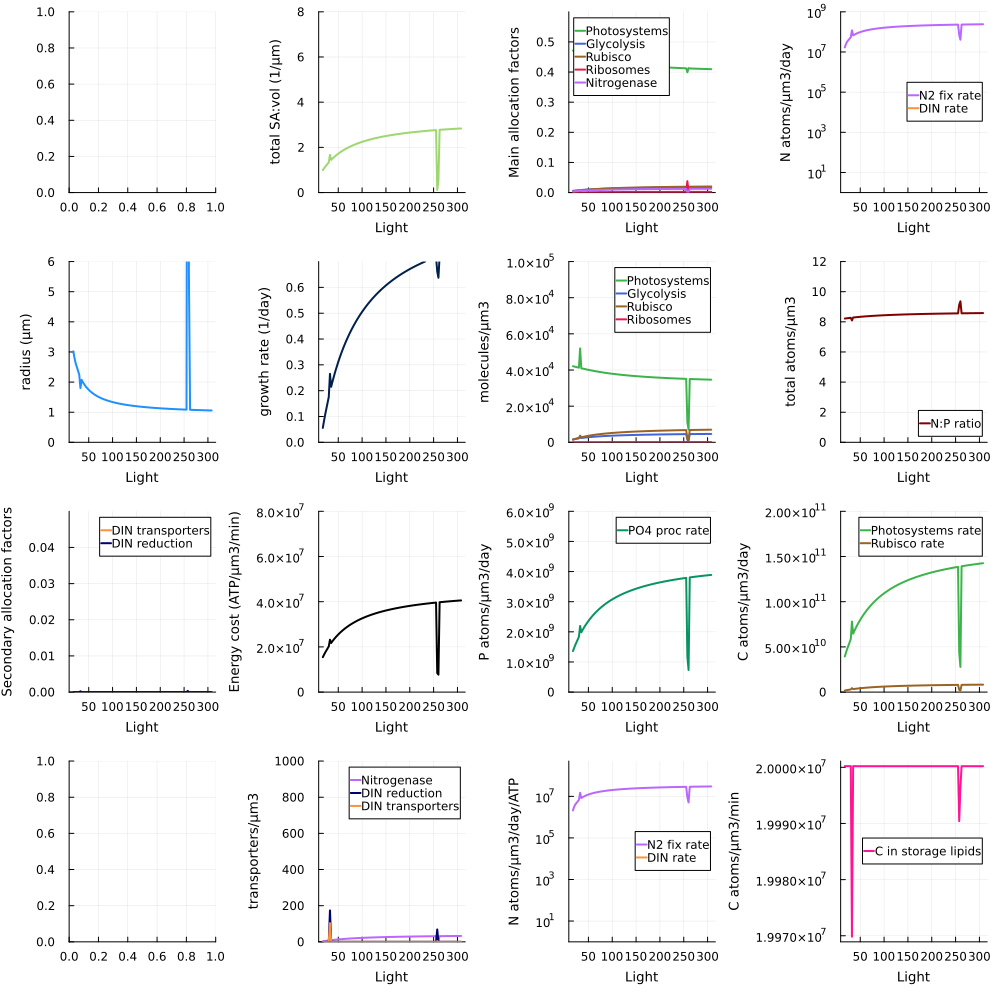

In [1950]:
# Making the plot
tic = 10.0 .^ collect(range(1,10,step=2))
tic1 = 10.0 .^ collect(range(1,10,step=1))
plot(layout = (4,4), guidefontsize = 9)

# plot!(filtered_df.light, (h_plot), color = "#01cdfe",  label = "length (μm)", xlabel = env , linewidth=2, ylabel = "cell dimensions (μm)", subplot = 1, ylims=(0,20),  legend=:bottomright)

# plot!(filtered_df.light, transporter_sa_vol_plot,  color = "#ff71ce", label = "transporters SA:vol", linewidth=2, subplot = 2, xlabel = env* "(μM)")
plot!(filtered_df.light,  filtered_df.beta,  color = "#9ed670", ylabel = "total SA:vol (1/μm)", linewidth=2, subplot = 2, legend=:topright, xlabel = env , label=false, ylims=(0,8))

plot!(filtered_df.light,  filtered_df.ichl,  color = "#3cb44b", label = "Photosystems", xlabel = env , ylabel = "Main allocation factors",linewidth=2, subplot = 3, ylims=(0,0.6), legend=:topleft)
plot!(filtered_df.light, filtered_df.icbd, color = "#4363d8",   label = "Glycolysis", subplot = 3, linewidth=2)
plot!(filtered_df.light, filtered_df.irub, color = "#9A6324",   label = "Rubisco", subplot = 3, linewidth=2, ylabel = "Main allocation factors", xlabel = env )
plot!(filtered_df.light, filtered_df.irib, color = "#e6194B",  label = "Ribosomes", linewidth=2, subplot = 3)
plot!(filtered_df.light,  filtered_df.init,  color = "#b967ff", label = "Nitrogenase", linewidth=2, subplot = 3)

plot!(filtered_df.light,  filtered_df.vnt*60*24,  color = "#b967ff", label = "N2 fix rate", xlabel = env , legend=:right, ylabel = "N atoms/μm3/day", linewidth=2, subplot = 4,  yaxis=:log10, yticks=tic, ylims=(1e0,1e9))#, yticks=tic, yaxis=:log10)#, yticks=0:0.3e8:2.2e8)
plot!(filtered_df.light,  filtered_df.vtrn*60*24,  color = "#fc913a", label = "DIN rate", linewidth=2, subplot = 4)

plot!(filtered_df.light, 3 ./filtered_df.beta, color = "#1E90FF",  label = false, linewidth=2, subplot = 5, xlabel = env , ylims=(0,6), ylabel = "radius (μm)", legend=:topright)

plot!(filtered_df.light, filtered_df.mu, color = "#011f4b", linewidth=2, subplot = 6, ylabel = "growth rate (1/day)", label = "", legend=:topright,  xlabel = env , ylims=(0,0.7))

plot!(filtered_df.light, filtered_df.cp, color = "#3cb44b",  label = "Photosystems", xlabel = env , linewidth=2, subplot = 7)
plot!(filtered_df.light, filtered_df.cgl, color = "#4363d8",  label = "Glycolysis", linewidth=2, subplot = 7)
plot!(filtered_df.light, filtered_df.cru, color = "#9A6324",  label = "Rubisco", linewidth=2, subplot = 7, ylabel = "molecules/μm3", ylims=(0,100000))
plot!(filtered_df.light, filtered_df.cri, color = "#e6194B",  label = "Ribosomes", linewidth=2, subplot = 7)

# plot!(filtered_df.light, filtered_df.Qc, color = "#800000",  label = "C", xlabel = env , ylabel = "total atoms/μm3", linewidth=2, subplot = 8, ylims=(1e0,2e11), legend=:bottomright, xlims=(0,2))
# plot!(filtered_df.light, filtered_df.Qn, color = "#469990",  label = "N", xlabel = env , linewidth=2, subplot = 8, yaxis=:log10, yticks=tic)
# plot!(filtered_df.light, filtered_df.Qp, color = "blue",  label = "P", xlabel = env , linewidth=2, subplot = 8)
plot!(filtered_df.light, filtered_df.Qn ./ filtered_df.Qp, color = "#800000",  label = "N:P ratio", xlabel = env , ylabel = "total atoms/μm3", linewidth=2, subplot = 8, ylims=(0,12), legend=:bottomright)

plot!(filtered_df.light,  filtered_df.itrn,  color = "#fc913a", label = "DIN transporters", linewidth=2, subplot = 9, legend=:topright, ylims=(0,0.05),  ylabel = "Secondary allocation factors", xlabel = env )
plot!(filtered_df.light,  filtered_df.idin,  color = "#000075", label = "DIN reduction", linewidth=2, subplot = 9)
# plot!(filtered_df.light,  filtered_df.itrpo4,  color = "#069460", label = "PO4 proc", linewidth=2, subplot = 9)

plot!(filtered_df.light, filtered_df.ecost, color = "black", xlabel = env, ylabel = "Energy cost (ATP/μm3/min)", linewidth=2, subplot = 10, ylims=(0,8e7), legend=false)

plot!(filtered_df.light,  filtered_df.vtrpo4*60*24,  color = "#069460", label = "PO4 proc rate", linewidth=2, subplot = 11, xlabel = env, ylabel = "P atoms/μm3/day", ylims=(0,6e9))

# plot!(filtered_df.light,  filtered_df.vri*60*24,  color = "#f032e6", label = "Ribosome rate", xlabel = env , legend=:bottomright, ylabel = "aa molec/μm3/day", linewidth=2, subplot = 11, ylims=(0,1e6), xlims=(0,2))

plot!(filtered_df.light,  filtered_df.vp*60*24,  color = "#3cb44b", label = "Photosystems rate", linewidth=2, subplot = 12, ylims=(0,2e11))
plot!(filtered_df.light,  filtered_df.phot*60*24,  color = "#9A6324", label = "Rubisco rate", xlabel = env , ylabel = "C atoms/μm3/day", linewidth=2, subplot = 12)

# plot!(filtered_df.light,  filtered_df.ctrn./filtered_df.clip,  color = "#0086ad", ylabel = "Membrane DIN transporter:lipid", linewidth=2, subplot = 13, yformatter = :scientific, xlabel = env , legend=false)

plot!(filtered_df.light, filtered_df.cnt, color = "#b967ff", label = "Nitrogenase", linewidth=2, subplot = 14, ylims=(0,1000))
plot!(filtered_df.light, filtered_df.cdin, color = "#000075", label = "DIN reduction", linewidth=2, subplot = 14)
plot!(filtered_df.light, filtered_df.ctrn, color = "#fc913a", label = "DIN transporters", xlabel = env , linewidth=2, subplot = 14, ylabel = "transporters/μm3")#, ylims=(0,600))

# plot!(filtered_df.light,  filtered_df.clm_plot,  color = "#a2778f", label = "Membrane lipids", linewidth=2, subplot = 15, legend=:bottomright, xlabel = env , ylabel = "molecules/μm3", ylims=(0,1.5e6), xlims=(0,2))
plot!(filtered_df.light,  filtered_df.vnt*60*24 /e_nt,  color = "#b967ff", label = "N2 fix rate", xlabel = env , legend=:right, ylabel = "N atoms/μm3/day/ATP", linewidth=2, subplot = 15)#, yaxis=:log10, yticks=tic1, ylims=(1e0,5e5))#, yticks=tic, yaxis=:log10)#, yticks=0:0.3e8:2.2e8)
plot!(filtered_df.light,  filtered_df.vtrn*60*24 /(e_trn+e_din),  color = "#fc913a", label = "DIN rate", linewidth=2, subplot = 15, yaxis=:log10, yticks=tic, ylims=(1e0,5e8))

plot!(filtered_df.light, filtered_df.ctag, color = "deeppink", ylabel = "C atoms/μm3/min", label = "C in storage lipids", linewidth=2, subplot = 16, legend=:right, xlabel = env )

plot!(size=(1000,1000))
# savefig("temperature_envP_noDIN_spheres.pdf")

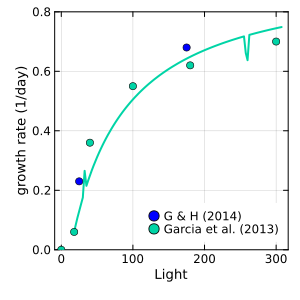

In [1951]:
plot(layout = (1,1), guidefontsize = 9)
plot!(filtered_df.light, filtered_df.mu, color = "#00d4a6", label = "", xlabel = env, ylabel = "growth rate (1/day)", linewidth=2, subplot = 1, legend=:bottomright, ylims = (0,0.8), framestyle=:box)
scatter!([25,175], [0.23,0.68], subplot = 1, color = "blue", label = "G & H (2014)", foreground_color_legend = nothing)
scatter!([0,18,40,100,180,300], [0,0.06,0.36,0.55,0.62,0.7], subplot = 1, color = "#00d4a6", label = "Garcia et al. (2013)", foreground_color_legend = nothing)

plot!(size=(300,300))
# savefig("Croco_validation_light_Garcia.pdf") 